First, we import all the libraries

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st

Then, we import the data using pandas for reading the .csv archive

In [2]:
df = pd.read_csv('/datasets/games.csv')

Review the Data Frame using the info() method

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Rename the columns according to the snake_case

In [4]:
columns_new = []
for old_name in df.columns:
    name_stripped = old_name.strip()
    name_lowered = name_stripped.lower()
    name_no_spaces = name_lowered.replace(' ','_')
    columns_new.append(name_no_spaces)

df.columns = columns_new

Verify that the data type is the expected for each column and make the neccesary modifications

In [5]:
print(df.sample(10))
df.info()

                                     name platform  year_of_release  \
3193           White Knight Chronicles II      PS3           2010.0   
6926                        We Love Golf!      Wii           2007.0   
13535                     Life is Strange       PC           2016.0   
7605                           Famista 64      N64              NaN   
9178             Odin Sphere: Leifthrasir      PSV           2016.0   
7824                               Sudeki       XB           2004.0   
6201     Medieval Moves: Deadmund's Quest      PS3           2011.0   
3443                     MLB 11: The Show      PS3           2011.0   
9886                          Psychonauts       XB           2005.0   
12263  Full Spectrum Warrior: Ten Hammers      PS2           2006.0   

              genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
3193   Role-Playing      0.23      0.09      0.27         0.04          60.0   
6926         Sports      0.19      0.00      0.03         

year_of_release column should be int instead of float. But we have to drop the null spaces first, considering that we have 15715 data and just 269 nulls (~1.6%) randomly distributed (any relation with genre or platform) i choosed the method dropna() that eliminate every nulls row. Also, we could save some rows by manually writing the year on the column, which is included in the title of some games like FIFA Soccer 2004.

In [6]:
print(df['year_of_release'].isna().sum())
print(df[df['year_of_release'].isna()].head())

269
                           name platform  year_of_release     genre  na_sales  \
183             Madden NFL 2004      PS2              NaN    Sports      4.26   
377            FIFA Soccer 2004      PS2              NaN    Sports      0.59   
456  LEGO Batman: The Videogame      Wii              NaN    Action      1.80   
475  wwe Smackdown vs. Raw 2006      PS2              NaN  Fighting      1.57   
609              Space Invaders     2600              NaN   Shooter      2.36   

     eu_sales  jp_sales  other_sales  critic_score user_score rating  
183      0.26      0.01         0.71          94.0        8.5      E  
377      2.36      0.04         0.51          84.0        6.4      E  
456      0.97      0.00         0.29          74.0        7.9   E10+  
475      1.02      0.00         0.41           NaN        NaN    NaN  
609      0.14      0.00         0.03           NaN        NaN    NaN  


In [7]:
df = df.dropna(subset=['year_of_release'])
print(df['year_of_release'].isna().sum())
#df.info()
df['year_of_release']= df['year_of_release'].astype('int')

0


Change every column with object type to string, so we can use the string methods and homogenize the logic.

In [8]:
df['name']= df['name'].astype('string')
df['platform']= df['platform'].astype('string')
df['genre']= df['genre'].astype('string')
df['rating']= df['rating'].astype('string')
#df.info()

The 'critic_score' and 'user_score' columns should be numeric to analyze trends in video game ratings. These columns contain many null values, possibly because the game is recent (marked "tbd") and lacks reviews, or because the collected data is insufficient. While we could fill these gaps using the mean or median calculated after statistically analyzing the rating distribution by genre or platform, but, given the hypothesis tests to be performed next, we wont fill those values because it would create artificial differences or similarities.

In [9]:
df['user_score']= pd.to_numeric(df['user_score'], errors = 'coerce')
df['critic_score']= df['critic_score'].astype("Int64")
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16446 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  string 
 1   platform         16446 non-null  string 
 2   year_of_release  16446 non-null  int64  
 3   genre            16444 non-null  string 
 4   na_sales         16446 non-null  float64
 5   eu_sales         16446 non-null  float64
 6   jp_sales         16446 non-null  float64
 7   other_sales      16446 non-null  float64
 8   critic_score     7983 non-null   Int64  
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   string 
dtypes: Int64(1), float64(5), int64(1), string(4)
memory usage: 1.5 MB


Now every column has the expected data type and we can create a new column for the total sales (including the 3 regions) of each game.

In [10]:
df['total_sales'] = df['na_sales'] + df['eu_sales']+ df['jp_sales']+ df['other_sales']

Review the releases per year by using a frecuency histogram

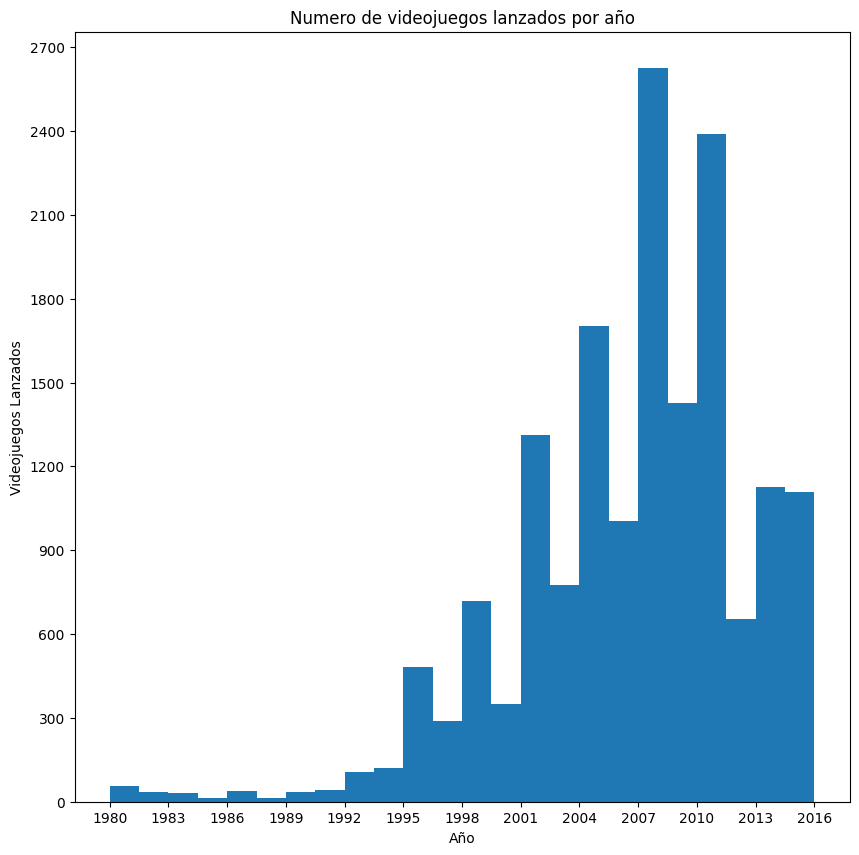

In [11]:
df['year_of_release'].plot(kind='hist',title='Videogames released per year', bins=24,figsize=[10,10])
plt.xlabel('Year')
plt.ylabel('Released Videogames')
plt.xticks(range(1980,2017,3))
plt.yticks(range(0,2800,300))
plt.show()

Note that the videogame releases on the 80's are very low, whereas there is a significant increase in the late 90's, followed by a peak in the 2000s. All this data is useful for identifying the genres most frequently produced during each period. Then, we analyze sales by platform.

In [12]:
print(df[['platform','total_sales']].groupby('platform').sum().sort_values(by='total_sales'))

          total_sales
platform             
PCFX             0.03
GG               0.04
3DO              0.10
TG16             0.16
WS               1.42
NG               1.44
SCD              1.86
DC              15.95
GEN             30.77
SAT             33.59
PSV             53.81
WiiU            82.19
2600            86.48
XOne           159.32
GC             196.73
SNES           200.04
N64            218.01
NES            251.05
XB             251.57
GB             254.43
PC             255.76
3DS            257.81
PSP            289.53
GBA            312.88
PS4            314.14
PS             727.58
DS             802.78
Wii            891.18
PS3            931.34
X360           961.24
PS2           1233.56


The top 6 succesful platforms (considering sales) are the PS, DS, Wii, PS3, X360, and PS2. We will analyze three of them to see how their sales performed over time.

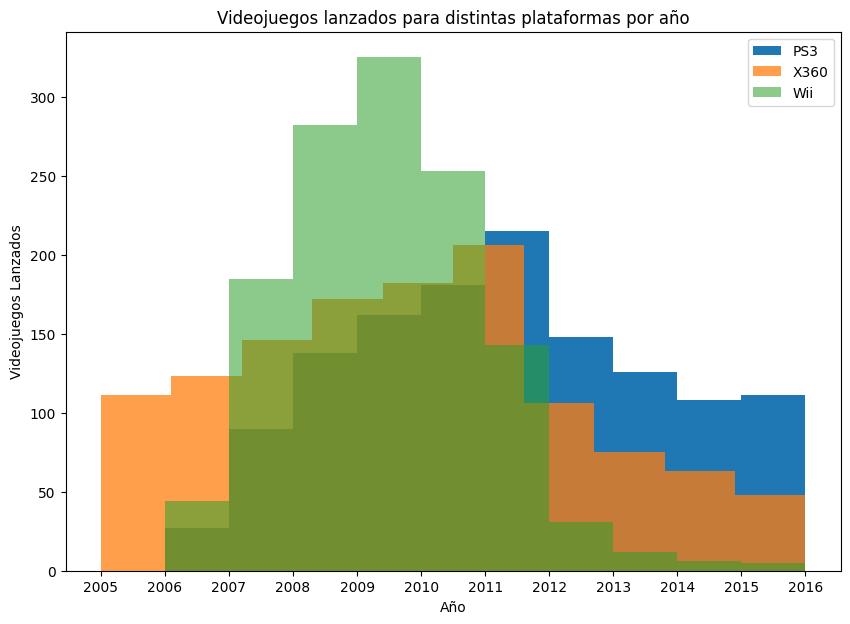

In [13]:
df[df['platform'] == 'PS3']['year_of_release'].plot(kind='hist',title='Videogames released per year and top platform',legend=True, figsize=[10,7])
df[df['platform'] == 'X360']['year_of_release'].plot(kind='hist',alpha=0.75,legend=True)
df[df['platform'] == 'Wii']['year_of_release'].plot(kind='hist',alpha=0.55,legend=True)
plt.xlabel('Year')
plt.ylabel('Released Videogames')
plt.legend(['PS3','X360','Wii'])
plt.xticks(range(2005,2017,1))
plt.show()

Analize the historical behavior of popular platforms that were popular at the time but no longer generate sales.

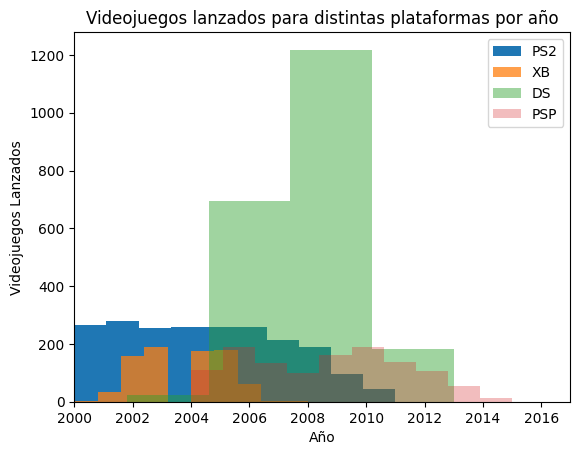

In [14]:
df[df['platform'] == 'PS2']['year_of_release'].plot(kind='hist',title='Videogames released per year and top platform',legend=True)
df[df['platform'] == 'XB']['year_of_release'].plot(kind='hist',alpha=0.75,legend=True)
df[df['platform'] == 'DS']['year_of_release'].plot(kind='hist',alpha=0.45,legend=True)
df[df['platform'] == 'PSP']['year_of_release'].plot(kind='hist',alpha=0.3,legend=True)
plt.xlabel('Year')
plt.ylabel('Released Videogames')
plt.legend(['PS2','XB','DS','PSP'])
plt.xlim(2000,2017)
plt.show()

Observe that platforms remain active for about 10 years before a newer generation emerges to replace them entirely. With this in mind, we will consider only data from 2011 onwards for our 2017 projections (thereby excluding older platforms that are no longer relevant today); to do this, we filter the DataFrame. To identify the most viable current platforms, we will analyze the distribution of the most recent ones:

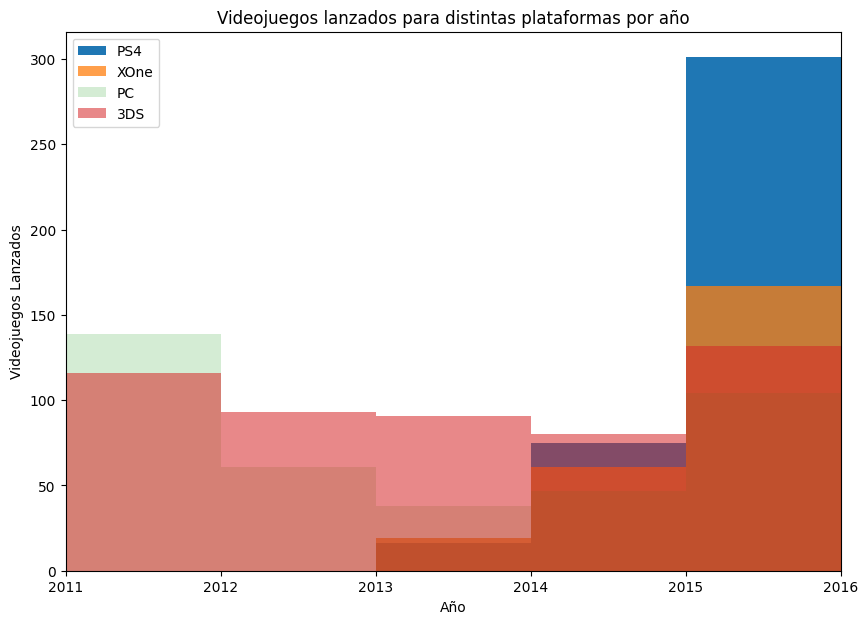

In [15]:
df = df[df["year_of_release"] >= 2011]

df[df['platform'] == 'PS4']['year_of_release'].plot(kind='hist', bins=3, title='Videogames released per year and top platform',legend=True, figsize=[10,7])
df[df['platform'] == 'XOne']['year_of_release'].plot(kind='hist',bins=3, alpha=0.75,legend=True)
df[df['platform'] == 'PC']['year_of_release'].plot(kind='hist', bins=5, alpha=0.2,legend=True)
df[df['platform'] == '3DS']['year_of_release'].plot(kind='hist',bins=5, alpha=0.55,legend=True)
plt.xlabel('Year')
plt.ylabel('Released Videogames')
plt.legend(['PS4','XOne','PC','3DS'])
plt.xticks(range(2011,2017,1))
plt.xlim(2011,2016)
plt.show()

Note that the most popular emerging platforms (by far) are PS4 and XOne that have been growing in the last 3 years, on the other hand, the 3DS has remained stable in terms of popularity despite being two years older, and the PC has also managed to maintain its popularity over time. As the main platform, we could choose PS4 and secondarily XOne in conjunction with PC since a longer viability time would be expected because they are newer than 3DS. 
We move on to observe the dispersion of total sales by platform:

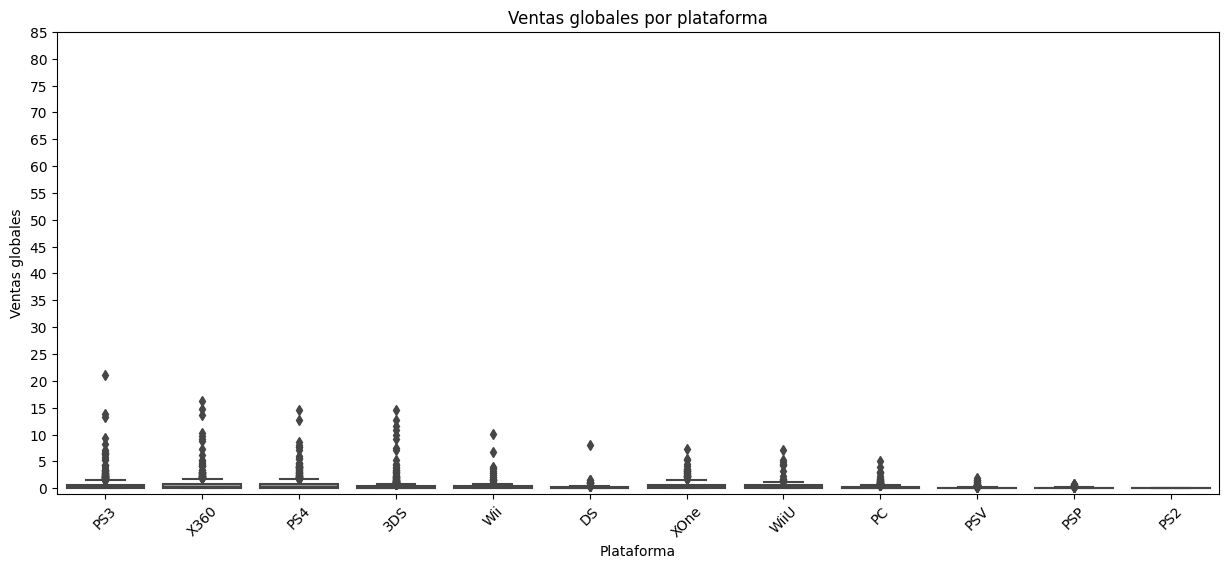

In [16]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df,x='platform',y='total_sales')
plt.title("Global sales by platform")
plt.xlabel("Platform")
plt.ylabel("Global Sales")
plt.yticks(range(0,90,5))
plt.xticks(rotation=45)
plt.show()

Almost all platforms have outliers, driven by games that are sales hits (around $5 million). However, the interquartile range for all platforms is less than $3 million.
Now analyze the correlation between user ratings and sales for the leading platform (PS4); this will provide significant insight into whether the highest-rated games are truly the ones generating the most sales.

-0.03088781296873357


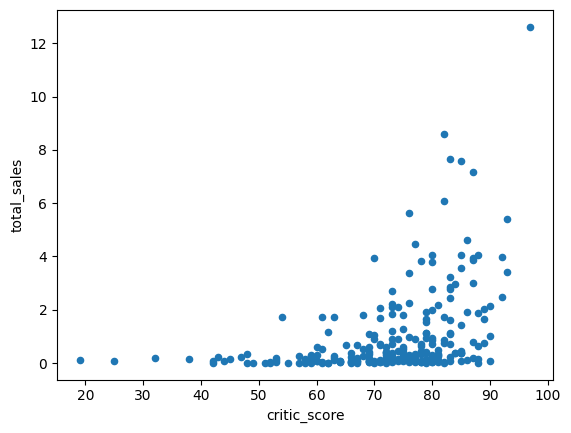

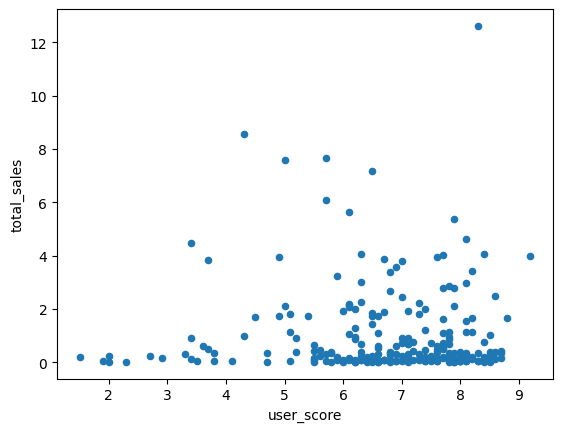

In [35]:
df[df['platform'] == 'PS4'].dropna().plot(x='critic_score',y='total_sales',kind='scatter')
df[df['platform'] == 'PS4'].dropna().plot(x='user_score',y='total_sales',kind='scatter')
print(df[df['platform'] == 'PS4'].dropna()['total_sales'].corr(df[df['platform'] == 'PS4'].dropna()['user_score']))

First scatter plot shows that there is indeed a slight positive relationship between critic ratings and sales; however, regarding user ratings (second plot), we observe significant data dispersion. Coupled with a Pearson correlation coefficient of approximately -0.031 (indicating a negligible negative linear relationship) we conclude that a videogame success depends on factors beyond just user ratings. Furthermore, the relationship is not strictly linear, partly due to the high degree of data dispersion, which may stem from a lack of consistent criteria among users when assigning ratings.

Now, lets identify the games that have been sold on more than one platform (multiplatform):

                                  name platform  total_sales
0                 Frozen: Olaf's Quest      3DS         0.59
1                 Frozen: Olaf's Quest       DS         0.51
2           2014 FIFA World Cup Brazil     X360         0.43
3           2014 FIFA World Cup Brazil      PS3         0.61
4    3rd Super Robot Wars Z Jigoku Hen      PS3         0.23
5    3rd Super Robot Wars Z Jigoku Hen      PSV         0.19
6  3rd Super Robot Wars Z: Tengoku-Hen      PS3         0.15
7  3rd Super Robot Wars Z: Tengoku-Hen      PSV         0.19
8                        7 Days to Die     XOne         0.05
9                        7 Days to Die      PS4         0.14


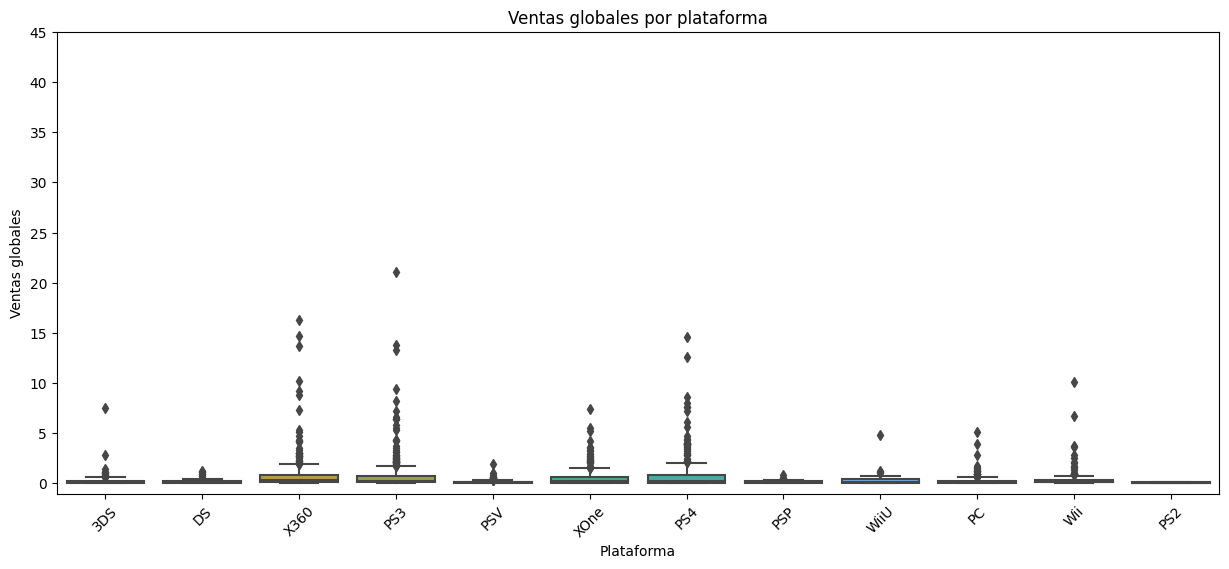

          total_sales
platform             
3DS          0.312521
DS           0.237455
PC           0.283922
PS2          0.071667
PS3          0.713641
PS4          0.884335
PSP          0.153182
PSV          0.149734
Wii          0.511053
WiiU         0.302424
X360         0.793729
XOne         0.603080


In [18]:
multi_platform = (df.groupby("name")["platform"].nunique())
multi_platform = multi_platform[multi_platform > 1]
multi_platform_df = df[df['name'].isin(multi_platform.index)][['name','platform','total_sales']].sort_values('name').reset_index(drop=True)
print(multi_platform_df.head(10))
plt.figure(figsize=(15,6))
sns.boxplot(data=multi_platform_df,x='platform',y='total_sales')
plt.title("Global Sales by Platform")
plt.xlabel("Platform")
plt.ylabel("Global Sales")
plt.yticks(range(0,50,5))
plt.xticks(rotation=45)
plt.show()
print(multi_platform_df.groupby('platform').mean())

Observe that the margins on the graph have narrowed, and there are fewer outliers compared to when all games were included. This implies that, although sales of a single video game can vary considerably across multiple platforms, the margins are generally more stable due to the scarcity of isolated hits.
Next, we analyze sales by genre:

<StringArray>
[      'Action',      'Shooter', 'Role-Playing',       'Racing',
     'Platform',         'Misc',   'Simulation',       'Sports',
     'Fighting',    'Adventure',       'Puzzle',     'Strategy']
Length: 12, dtype: string


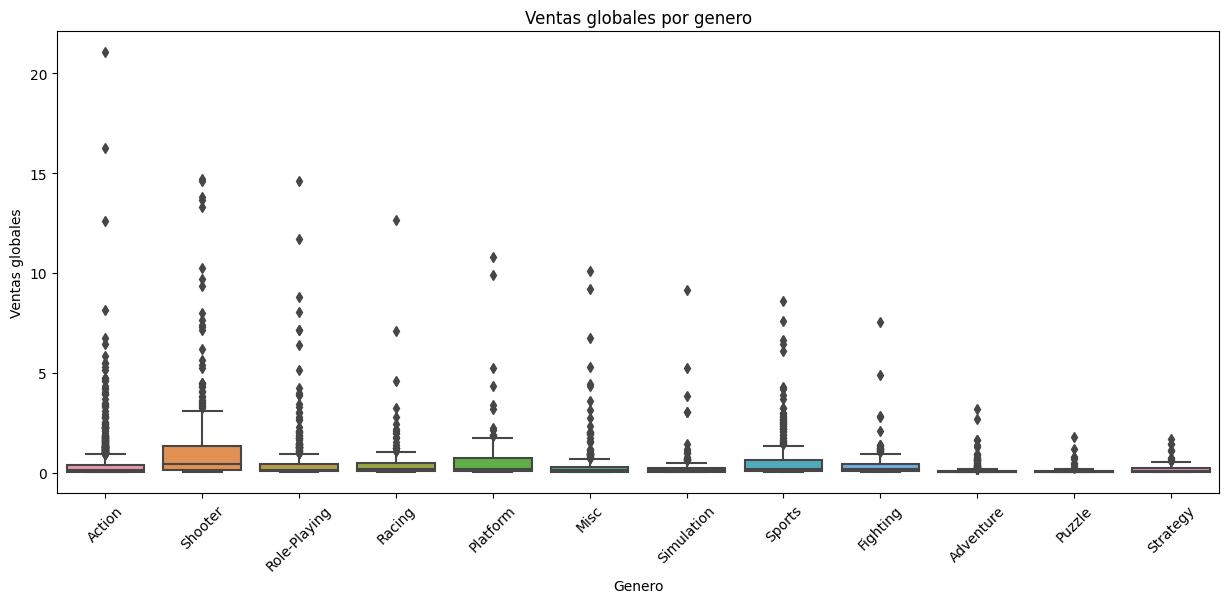

In [19]:
print(df['genre'].unique())
plt.figure(figsize=(15,6))
sns.boxplot(data=df,x='genre',y='total_sales')
plt.title("Global sales by genre")
plt.xlabel("Genre")
plt.ylabel("Global Sales")
plt.xticks(rotation=45)
plt.show()

Almost every genre have the same behavior, with outliers and interquartile ranges falling within the same zone. However, profit margins are lower for the Puzzle, Adventure, and Strategy genres (which also see very few sales hits [outliers]) while genres such as Shooter, Platform, and Sports exhibit a wider range and a significant number of outliers.

We analyze the North American (NA) region, starting with the top 5 platforms and genres, then examine the correlation between sales in that region and ESRB ratings

In [20]:
print(df.groupby('platform')['na_sales'].sum().sort_values().tail(5))

platform
3DS      82.65
XOne     93.12
PS4     108.74
PS3     168.26
X360    226.80
Name: na_sales, dtype: float64


In [21]:
print(df.groupby('genre')['na_sales'].sum().sort_values().tail(5))

genre
Misc             69.69
Role-Playing     83.78
Sports          108.70
Shooter         194.43
Action          230.92
Name: na_sales, dtype: float64


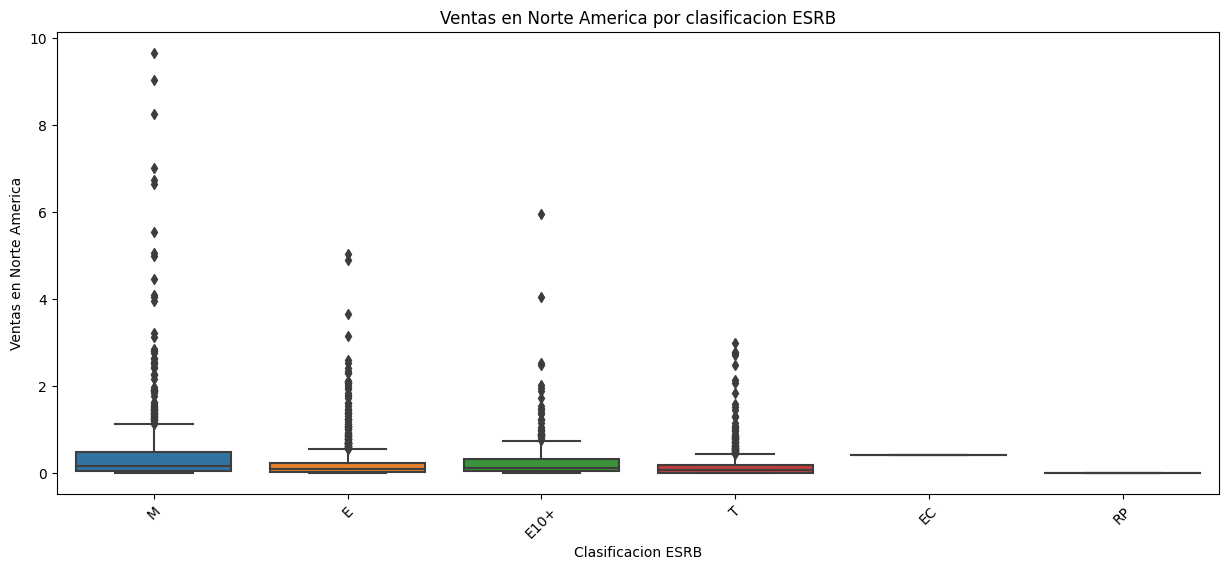

<AxesSubplot:title={'center':'Ventas totales en Norte America por clasificacion ESRB'}, xlabel='Clasificacion ESRB', ylabel='Ventas totales en Norte America'>

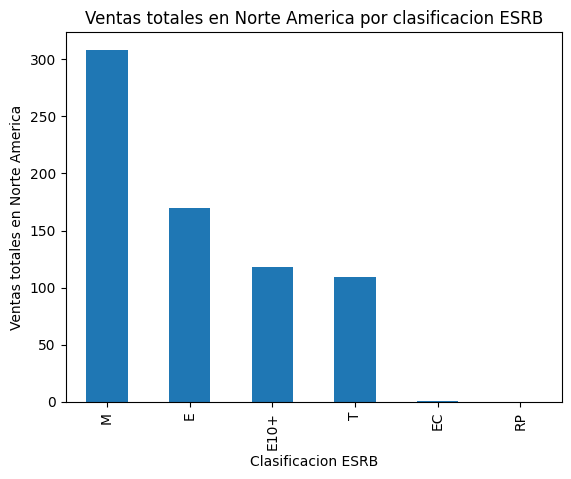

In [22]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df,x='rating',y='na_sales')
plt.title("Sales on North America by ESRB rating")
plt.xlabel("ESRB rating")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

na_df = (df.groupby("rating")["na_sales"].sum().sort_values(ascending=False))
na_df.plot(kind='bar',xlabel='ESRB rating',ylabel='Total sales on North Amercia', title= 'Total sales on North America by ESRB rating')

Then we do the same for the European Union region (UE):

In [23]:
print(df.groupby('platform')['eu_sales'].sum().sort_values().tail(5))

platform
PC       56.70
3DS      61.27
X360    117.10
PS4     141.09
PS3     163.10
Name: eu_sales, dtype: float64


In [24]:
print(df.groupby('genre')['eu_sales'].sum().sort_values().tail(5))

genre
Racing           40.58
Role-Playing     62.30
Sports           88.48
Shooter         148.02
Action          199.12
Name: eu_sales, dtype: float64


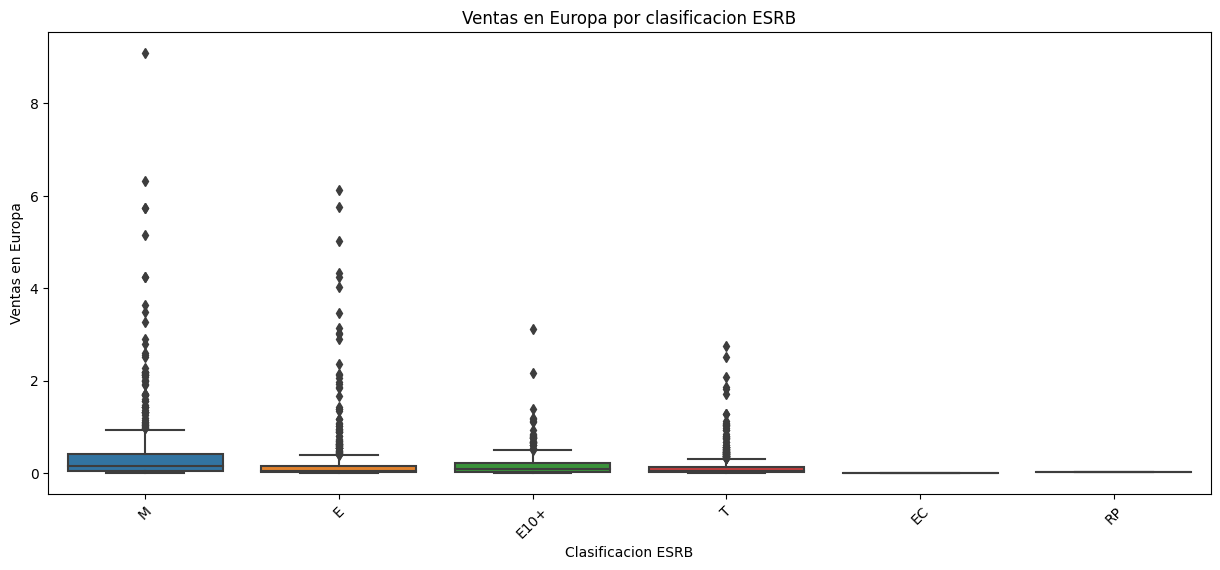

<AxesSubplot:title={'center':'Ventas totales en Europa por clasificacion ESRB'}, xlabel='Clasificacion ESRB', ylabel='Ventas totales en Europa'>

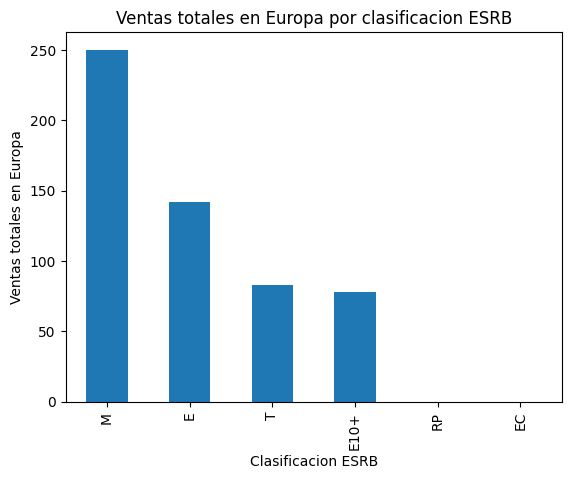

In [25]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df,x='rating',y='eu_sales')
plt.title("Sales on Europe by ESRB rating")
plt.xlabel("ESRB rating")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

eu_df = (df.groupby("rating")["eu_sales"].sum().sort_values(ascending=False))
eu_df.plot(kind='bar',xlabel='ESRB rating',ylabel='Total sales on Europe', title= 'Total sales on Europe by ESRB rating')

Finalmente, comparemos con los datos para la region de japon:

In [26]:
print(df.groupby('platform')['jp_sales'].sum().sort_values().tail(5))

platform
PS4     15.96
PSV     21.84
PSP     24.04
PS3     49.39
3DS    100.62
Name: jp_sales, dtype: float64


In [27]:
print(df.groupby('genre')['jp_sales'].sum().sort_values().tail(5))

genre
Platform        12.13
Fighting        12.38
Misc            17.60
Action          63.62
Role-Playing    79.87
Name: jp_sales, dtype: float64


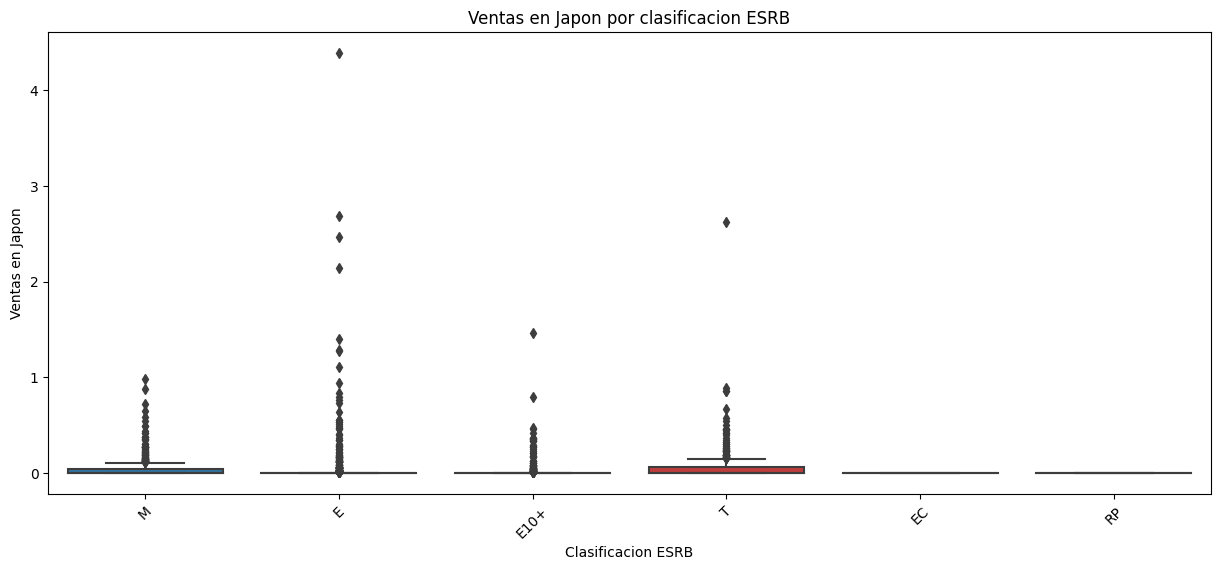

<AxesSubplot:title={'center':'Ventas totales en Japon por clasificacion ESRB'}, xlabel='Clasificacion ESRB', ylabel='Ventas totales en Japon'>

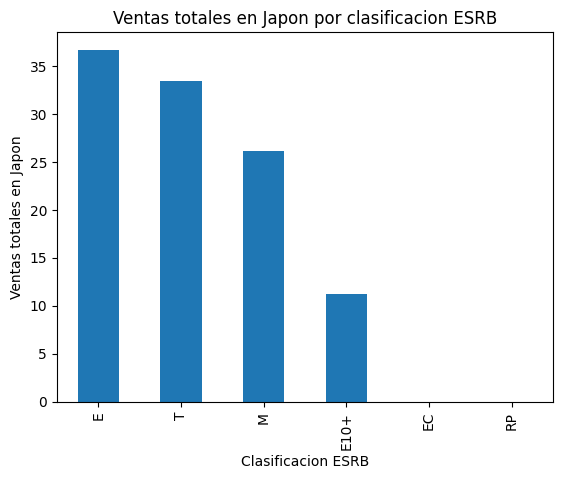

In [28]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df,x='rating',y='jp_sales')
plt.title("Sales on Japan by ESRB rating")
plt.xlabel("ESRB rating")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

eu_df = (df.groupby("rating")["jp_sales"].sum().sort_values(ascending=False))
eu_df.plot(kind='bar',xlabel='ESRB rating',ylabel='Total sales on Japan', title= 'Total sales on Japan by ESRB rating')


E, M, and T ratings are the most successful across all regions; furthermore, the rating appears to have a more direct impact on sales in North America and Europe than in Japan, where the impact seems less direct due to the relatively low number of outliers. We also note that the top selling platforms across all regions are the X360, PS3, PS4, and 3DS (highlighting the absence of Xbox in Japan and Sony's market leadership), although revenue varies significantly by region: North America generates the most revenue, followed by Europe and then Japan at least based on the available data.
Regarding the most popular genres Action, Sports, Shooter, and Role-Playing lead in sales.

We now formulate the null hypothesis that the average user ratings for the Xbox One and PC platforms are the same, while the alternative hypothesis states that they are different. We will use an alpha of 0.05 and, during the process, remove null values to avoid errors with the algorithm:

In [29]:
alpha=0.05
results = st.ttest_ind(df[df['platform']=='XOne']['user_score'].dropna(),df[df['platform']=='PC']['user_score'].dropna(),equal_var=False)
print(f"En valor P es: {results.pvalue}")
if results.pvalue < alpha:
    print('We reject the null hypothesis')
else:
    print('We can't reject the null hypothesis')

En valor P es: 0.6130712247638477
No podemos rechazar la hipotesis nula


This hypothesis test indicates that, based on the available data, there is statistical evidence to suggest the average rating given by Xbox users is equal to that of PC users, with a p-value of 0.61 indicating a high degree of similarity.

Finally, we establish a null hypothesis stating that the average ratings from users of the Action genre are equal to those of the Sports genre; consequently, the alternative hypothesis posits that they are significantly different:

In [30]:
alpha=0.05
results = st.ttest_ind(df[df['genre']=='Action']['user_score'].dropna(),df[df['genre']=='Sports']['user_score'].dropna(),equal_var=False)
print(f"En valor P es: {results.pvalue}")
if results.pvalue < alpha:
    print('We reject the null hypothesis')
else:
    print('We can't reject the null hypothesis')

En valor P es: 8.285648549432565e-19
Rechazamos la hipotesis nula


With such a small p-value (close to 0), we conclude that, for the data analyzed, there is no statistical evidence to suggest that the Action and Sports genres are rated similarly; in other words, they differ from one another.

## General Conclusions

Based on the data analysis, we can conclude that launching a video game with a high probability of success in 2017 requires considering emerging platforms, such as the Xbox One or PS4 (both launched in 2013), which typically remain active for around ten years. Depending on the game's genre and format, one might also choose platforms like Nintendo, which offers high profit margins, or PC, which demonstrates consistent revenue over time.

We can discard user ratings (though not critic reviews) and multi-platform releases as significant factors affecting average sales revenue. Regarding genre, the action, sports, shooter, and role-playing game (RPG) categories show the highest sales figures. In terms of ESRB ratings, the E, M, and T categories have been the most successful since 2011.

Finally, we observe that the North American region generates more revenue than Europe and Japan.